In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

labels = np.loadtxt('data/y.txt')
labels = labels - np.mean(labels)
path = 'data/dataset/dataset.csv'

def processMatrix(matrix):
    matrix = pd.read_csv(path, header=None)
    # Elimino la primera fila y columna que son los nombres de las columnas y filas
    matrix = matrix.drop(0, axis=0)
    matrix = matrix.drop(0, axis=1)
    
    # elimina las ultimas 6 columnas
    # matrix = matrix.drop(matrix.columns[:104], axis=1)
    # Elimino las primeras 100 columnas
    # matrix = matrix.drop(matrix.columns[100:], axis=1)


    # Convierto la matriz a un array de numpy
    matrix = matrix.to_numpy()
    matrix = matrix - np.mean(matrix, axis=0) # esta cosa centra la matriz

    return matrix

def euclidean_distances(X):
    # Calculamos la matriz de productos internos
    XXT = X @ X.T
    # Extraemos la diagonal (normas cuadradas de cada punto)
    norms = np.diag(XXT)
    # Calculamos la matriz de distancias euclidianas usando broadcasting
    distances = np.sqrt(norms[:, np.newaxis] + norms[np.newaxis, :] - 2 * XXT)
    return distances

def similarity_matrix(matrix, deviation):
    # diff = matrix[:, None] - matrix
    # dist_sq = np.einsum('ijk,ijk->ij', diff, diff)
    # sim_matrix = np.exp(-np.sqrt(dist_sq) / (2 * deviation**2))
    sim_matrix = np.exp(-euclidean_distances(matrix) / (2 * deviation**2))
    return sim_matrix


def show_similarity_matrix(matrix, deviation):

    sim_matrix = similarity_matrix(matrix, deviation)

    plt.figure()
    plt.imshow(sim_matrix)
    plt.colorbar()
    plt.title(f"Matriz de similaritud con desviación {deviation}")
    plt.show()
    
def reduceDimensions(matrix, deviation, dimension):
    u, s, vt = np.linalg.svd(matrix, full_matrices=False)
    print(f"Dimensiones de U: {u.shape}")
    print(f"Dimensiones de S: {s.shape}")
    print(f"Dimensiones de Vt: {vt.shape}")
    print()    

    # Reducimos la dimensión de la matriz
    U_reduced = u[:, :dimension]
    S_reduced = np.diag(s[:dimension])
    matrix_svd = U_reduced @ S_reduced
    print(f"Dimensiones de MatrizSVD: {matrix_svd.shape}")
    
    sim_matrix = similarity_matrix(matrix_svd, deviation)
    sim_matrix_d10 = similarity_matrix(matrix_svd, 10)
    print(f"Dimensiones de MatrizSimilitudSVD: {sim_matrix.shape}")
    
    plt.figure()
    plt.imshow(sim_matrix)
    plt.colorbar()
    plt.title(f"Matriz de similaritud con desviación {deviation} y reducción de dimensiones a {dimension}")
    plt.show()
    
    plt.figure()
    plt.imshow(sim_matrix_d10)
    plt.colorbar()
    plt.title(f"Matriz de similaritud con desviación 10 y reducción de dimensiones a {dimension}")
    plt.show()
    
    if dimension == 2:
        plt.figure()
        plt.bar(range(len(s)), s)
        plt.title("Valores singulares")
        plt.xlabel("Número de valor singular")
        plt.ylabel("Varianza del valor singular")
        plt.show()
        
        plt.figure()
        plt.bar(range(len(vt[0])), (vt[0, :]))
        plt.title("Primer vector de Vt")
        plt.xlabel("Número de componente")
        plt.ylabel("Valor de la componente")
        plt.grid()
        plt.show()
        
        plt.scatter(matrix_svd[:, 0], matrix_svd[:, 1], c=labels, cmap='ocean', marker='o')
        plt.title(f"Reducción de dimensiones a {dimension}")
        plt.show()
        return
    elif dimension == 3:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(matrix_svd[:, 0], matrix_svd[:, 1], matrix_svd[:, 2], cmap='ocean', c=labels, marker='o')
        plt.title(f"Reducción de dimensiones a {dimension}")
        plt.show()
        return
    else:
        return
    
def iterateDimensions(matrix, deviation, dimensions):
        dimension = dimensions[0] 
        for i in range(1,5):
            print(f"Desviación: {deviation}")
            reduceDimensions(matrix, deviation, dimension)
            dimension = dimensions[i]  
    
def iterateDeviation(matrix):
    deviation = 10
    for i in range(5):
        print(f"Desviación: {deviation}")
        show_similarity_matrix(matrix, deviation)
        deviation = deviation/10
        

Desviación: 10


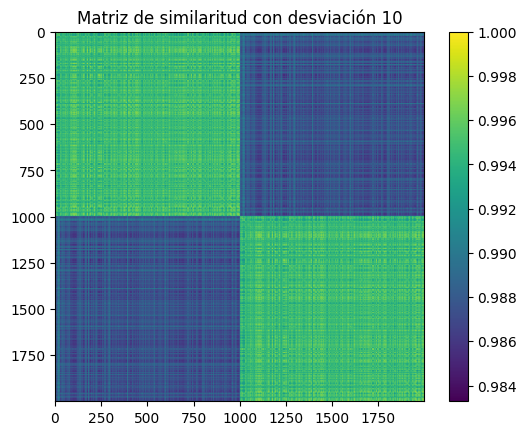

Desviación: 1.0


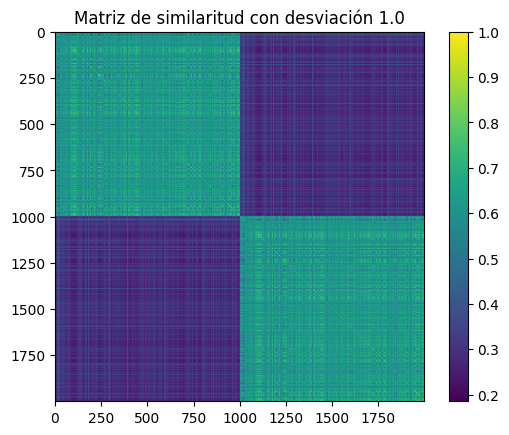

Desviación: 0.1


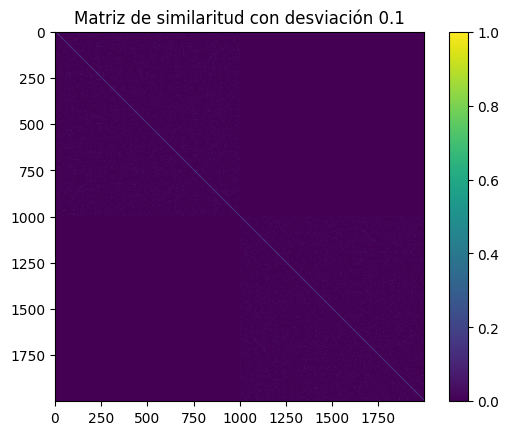

Desviación: 0.01


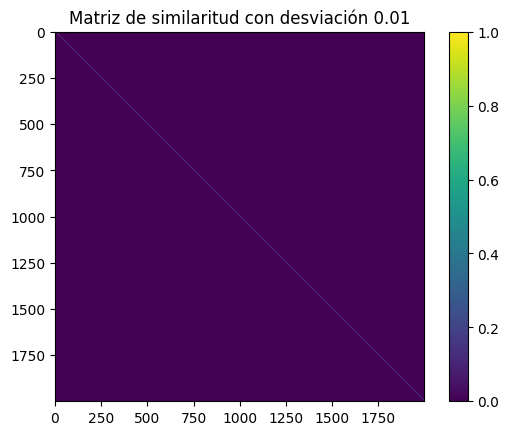

Desviación: 0.001


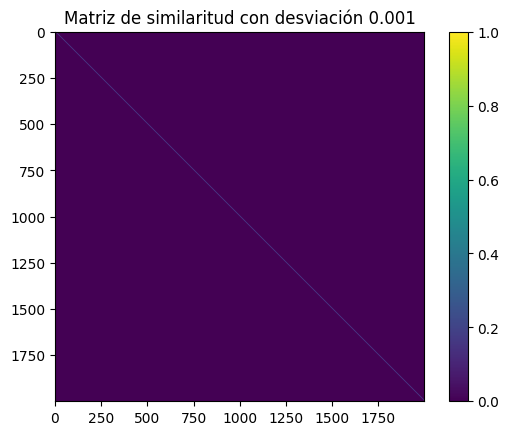

In [61]:
deviation = 1
dimensions = [2, 3, 6, 10, 20]

matrix = processMatrix(path)
iterateDeviation(matrix)

Desviación: 1
Dimensiones de U: (2000, 2)
Dimensiones de S: (2,)
Dimensiones de Vt: (2, 2)

Dimensiones de MatrizSVD: (2000, 2)
Dimensiones de MatrizSimilitudSVD: (2000, 2000)


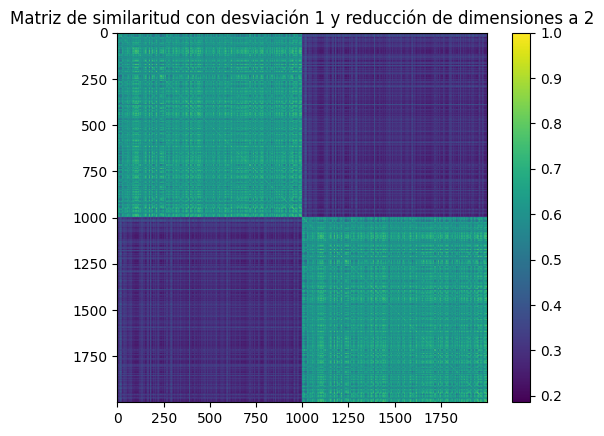

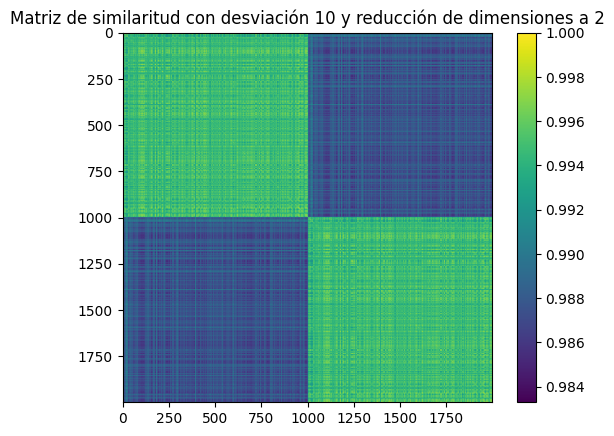

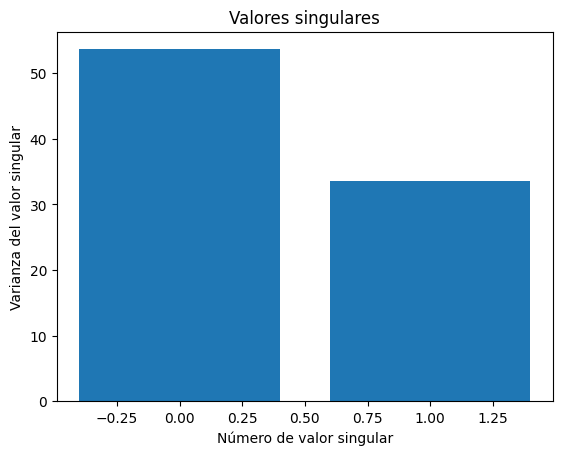

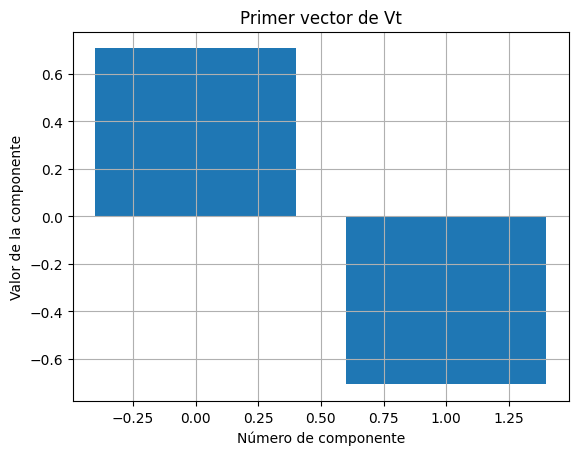

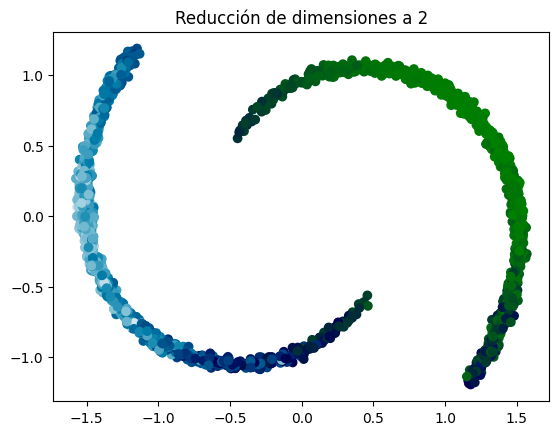

Desviación: 1
Dimensiones de U: (2000, 2)
Dimensiones de S: (2,)
Dimensiones de Vt: (2, 2)

Dimensiones de MatrizSVD: (2000, 2)
Dimensiones de MatrizSimilitudSVD: (2000, 2000)


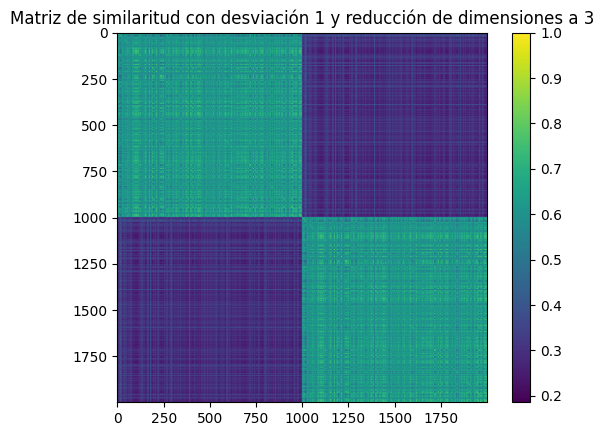

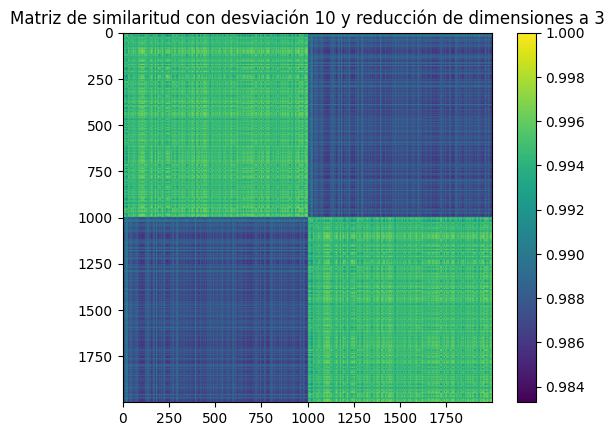

IndexError: index 2 is out of bounds for axis 1 with size 2

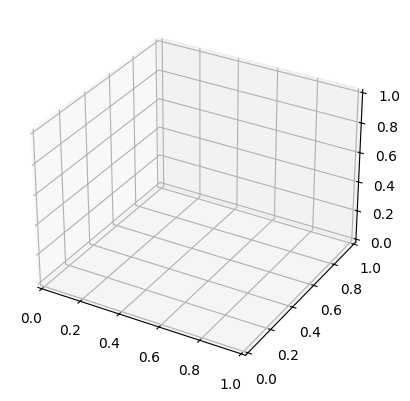

In [62]:
iterateDimensions(matrix, deviation, dimensions)


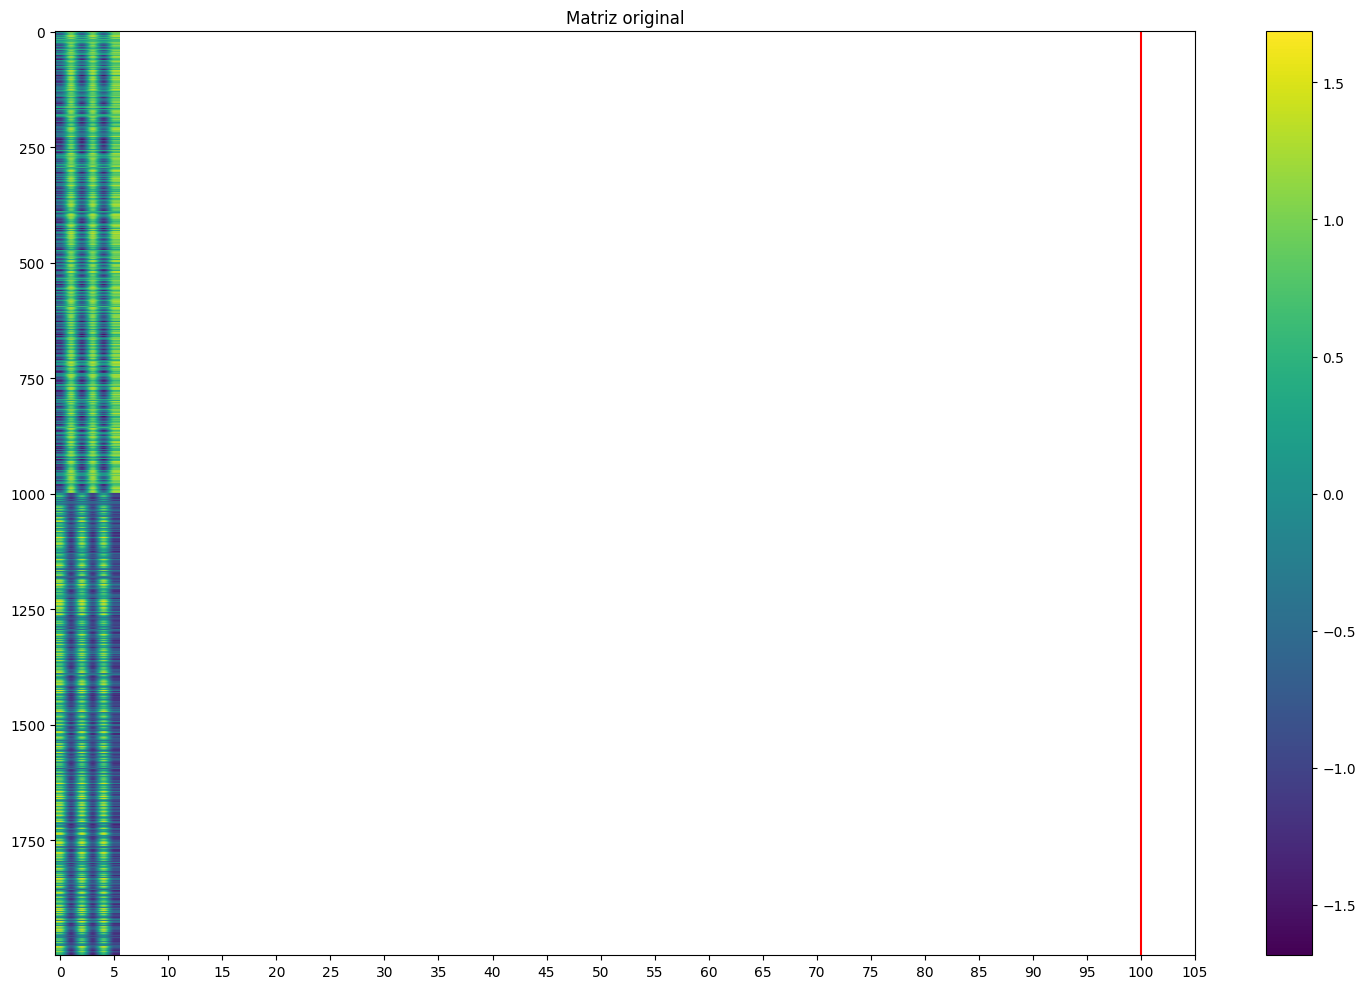

In [ ]:
plt.figure(figsize=(15, 10))  # Ajusta estos valores según tus necesidades
plt.imshow(matrix, aspect='auto')
plt.colorbar()
plt.title("Matriz original")
plt.xticks(range(0, 106, 5))
plt.tight_layout()
# hace una linea trazada en el eje X = 102
plt.axvline(x=100, color='r')
plt.show()

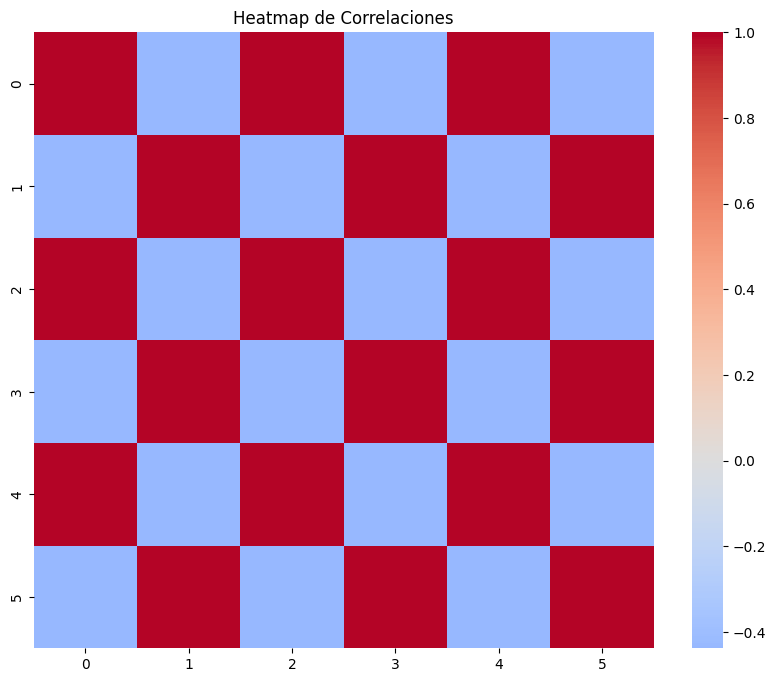

In [ ]:
import seaborn as sns
correlation_matrix = np.corrcoef(matrix.T)

# Plotear el heatmap de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Heatmap de Correlaciones')
plt.show()
